# Vecchia Temporal-Neighbor Ablation

Question: in simulated regular-grid data, do previous-lag local-neighbor locations help, and how do they compare with upstream-centered advection neighborhoods?

Compared models:

- `FullLagNbs`: fair same-location-centered baseline. `t` spatial neighbors + same location and same-location-centered local neighbors at `t-1` and `t-2`, using one extra standard temporal neighbor per lag to match the advec budget.
- `AdvecUpstreamCentered`: `t` spatial neighbors + same location + upstream center and upstream-centered local neighbors at `t-1` and `t-2`.
- `SameLocOnly`: `t` spatial neighbors + same location only at `t-1` and `t-2`. Diagnostic, not a fair budget-matched competitor.
- `SpatialRealloc`: same-location temporal lags only, but the removed lag-neighbor budget is reallocated to more `t` spatial neighbors. Diagnostic for spatial-budget reallocation.

Interpretation target: `FullLagNbs` tests Eulerian local temporal structure, while `AdvecUpstreamCentered` tests a stronger Lagrangian/advection-centered hypothesis under a comparable lag-wise conditioning budget.


In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.fft
import matplotlib.pyplot as plt

AMAREL_SRC = "/home/jl2815/tco"
LOCAL_SRC = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
_src = AMAREL_SRC if os.path.exists(AMAREL_SRC) else LOCAL_SRC
sys.path.insert(0, _src)

from GEMS_TCO import kernels_vecchia
from GEMS_TCO import kernels_vecchia_advec
from GEMS_TCO import orderings as _orderings

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
DELTA_LAT_BASE = 0.044
DELTA_LON_BASE = 0.063
T_STEPS = 8

print("DEVICE:", DEVICE)

DEVICE: cpu


## Experiment settings

For a quick local sanity check, use a smaller region and few iterations. For the full comparison, use the full region and raise `NUM_ITERS`.

In [2]:
# Quick local defaults. Change these for the full experiment.
LAT_RANGE = (-1.0, 1.0)      # full: (-3.0, 2.0)
LON_RANGE = (123.0, 126.0)   # full: (121.0, 131.0)
NUM_ITERS = 5                # full: 100 or 300
SEED = 42

SMOOTH = 0.5
MM_COND_NUMBER = 100
NHEADS = 0
DAILY_STRIDE = 2

BASE_LIMIT_A = 8
BASE_LIMIT_B = 8
BASE_LIMIT_C = 8
ADVEC_LON_OFFSET = DELTA_LON_BASE * 2  # t-1: lon + 0.126, t-2: lon + 0.252

LBFGS_STEPS = 3              # full: 5
LBFGS_EVAL = 20
LBFGS_HIST = 10
INIT_NOISE = 0.7

TRUE_DICT = {
    "sigmasq": 10.0,
    "range_lat": 0.30,
    "range_lon": 0.40,
    "range_time": 2.0,
    "advec_lat": 0.08,
    "advec_lon": -0.126,
    "nugget": 2.5,
}

MODEL_SPECS = {
    "FullLagNbs": {
        "kernel": "std",
        "limit_A": BASE_LIMIT_A,
        "limit_B": BASE_LIMIT_B + 1,
        "limit_C": BASE_LIMIT_C + 1,
        "description": "fair same-location-centered temporal neighborhoods",
    },
    "AdvecUpstreamCentered": {
        "kernel": "advec",
        "limit_A": BASE_LIMIT_A,
        "limit_B": BASE_LIMIT_B,
        "limit_C": BASE_LIMIT_C,
        "description": "same loc + upstream center + upstream-centered neighbors",
    },
    "SameLocOnly": {
        "kernel": "std",
        "limit_A": BASE_LIMIT_A,
        "limit_B": 0,
        "limit_C": 0,
        "description": "diagnostic: t spatial + same loc only at t-1/t-2",
    },
    "SpatialRealloc": {
        "kernel": "std",
        "limit_A": BASE_LIMIT_A + BASE_LIMIT_B + BASE_LIMIT_C,
        "limit_B": 0,
        "limit_C": 0,
        "description": "diagnostic: removed lag-neighbor budget reallocated to t spatial neighbors",
    },
}

MODEL_SPECS


{'FullLagNbs': {'kernel': 'std',
  'limit_A': 8,
  'limit_B': 9,
  'limit_C': 9,
  'description': 'fair same-location-centered temporal neighborhoods'},
 'AdvecUpstreamCentered': {'kernel': 'advec',
  'limit_A': 8,
  'limit_B': 8,
  'limit_C': 8,
  'description': 'same loc + upstream center + upstream-centered neighbors'},
 'SameLocOnly': {'kernel': 'std',
  'limit_A': 8,
  'limit_B': 0,
  'limit_C': 0,
  'description': 'diagnostic: t spatial + same loc only at t-1/t-2'},
 'SpatialRealloc': {'kernel': 'std',
  'limit_A': 24,
  'limit_B': 0,
  'limit_C': 0,
  'description': 'diagnostic: removed lag-neighbor budget reallocated to t spatial neighbors'}}

In [3]:
P_LABELS = ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]
P_COLS = ["sigmasq_est", "range_lat_est", "range_lon_est", "range_t_est", "advec_lat_est", "advec_lon_est", "nugget_est"]

def get_covariance_on_grid(lx, ly, lt, params):
    params = torch.clamp(params, min=-15.0, max=15.0)
    phi1, phi2, phi3, phi4 = (torch.exp(params[i]) for i in range(4))
    u_lat = lx - params[4] * lt
    u_lon = ly - params[5] * lt
    dist = torch.sqrt(u_lat.pow(2) * phi3 + u_lon.pow(2) + lt.pow(2) * phi4 + 1e-8)
    return (phi1 / phi2) * torch.exp(-dist * phi2)

def build_target_grid(lat_range, lon_range):
    lats = torch.arange(min(lat_range), max(lat_range) + 0.0001, DELTA_LAT_BASE, device=DEVICE, dtype=DTYPE)
    lons = torch.arange(lon_range[0], lon_range[1] + 0.0001, DELTA_LON_BASE, device=DEVICE, dtype=DTYPE)
    lats = torch.round(lats * 10000) / 10000
    lons = torch.round(lons * 10000) / 10000
    g_lat, g_lon = torch.meshgrid(lats, lons, indexing="ij")
    grid_coords = torch.stack([g_lat.flatten(), g_lon.flatten()], dim=1)
    return lats, lons, grid_coords

def generate_field_values(n_lat, n_lon, t_steps, params):
    cpu = torch.device("cpu")
    f32 = torch.float32
    px, py, pt = 2 * n_lat, 2 * n_lon, 2 * t_steps
    lx = torch.arange(px, device=cpu, dtype=f32) * DELTA_LAT_BASE
    lx[px // 2:] -= px * DELTA_LAT_BASE
    ly = torch.arange(py, device=cpu, dtype=f32) * DELTA_LON_BASE
    ly[py // 2:] -= py * DELTA_LON_BASE
    lt = torch.arange(pt, device=cpu, dtype=f32)
    lt[pt // 2:] -= pt
    params_cpu = params.cpu().float()
    Lx, Ly, Lt = torch.meshgrid(lx, ly, lt, indexing="ij")
    C = get_covariance_on_grid(Lx, Ly, Lt, params_cpu)
    S = torch.fft.fftn(C)
    S.real = torch.clamp(S.real, min=0)
    noise = torch.fft.fftn(torch.randn(px, py, pt, device=cpu, dtype=f32))
    field = torch.fft.ifftn(torch.sqrt(S.real) * noise).real[:n_lat, :n_lon, :t_steps]
    return field.to(device=DEVICE, dtype=DTYPE)

def assemble_reg_map(field, grid_coords, true_params, t_offset=21.0):
    nugget_std = torch.sqrt(torch.exp(true_params[6]))
    n_grid = grid_coords.shape[0]
    field_flat = field.reshape(n_grid, field.shape[-1])
    reg_map = {}
    for t_idx in range(field.shape[-1]):
        key = f"t{t_idx}"
        t_val = float(t_offset + t_idx)
        dummy = torch.zeros(7, device=DEVICE, dtype=DTYPE)
        if t_idx > 0:
            dummy[t_idx - 1] = 1.0
        rows = torch.zeros((n_grid, 11), device=DEVICE, dtype=DTYPE)
        rows[:, :2] = grid_coords
        rows[:, 2] = field_flat[:, t_idx] + torch.randn(n_grid, device=DEVICE, dtype=DTYPE) * nugget_std
        rows[:, 3] = t_val
        rows[:, 4:] = dummy.unsqueeze(0).expand(n_grid, -1)
        reg_map[key] = rows.detach()
    return reg_map

def compute_grid_ordering(grid_coords, mm_cond_number):
    coords_np = grid_coords.detach().cpu().numpy()
    ord_mm = _orderings.maxmin_cpp(coords_np)
    nns = _orderings.find_nns_l2(locs=coords_np[ord_mm], max_nn=mm_cond_number)
    return ord_mm, nns

def true_to_log_params(true_dict):
    phi2 = 1.0 / true_dict["range_lon"]
    phi1 = true_dict["sigmasq"] * phi2
    phi3 = (true_dict["range_lon"] / true_dict["range_lat"]) ** 2
    phi4 = (true_dict["range_lon"] / true_dict["range_time"]) ** 2
    return [np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4), true_dict["advec_lat"], true_dict["advec_lon"], np.log(true_dict["nugget"])]

def backmap_params(out_params):
    p = [x.item() if isinstance(x, torch.Tensor) else float(x) for x in out_params[:7]]
    phi2 = np.exp(p[1])
    phi3 = np.exp(p[2])
    phi4 = np.exp(p[3])
    rlon = 1.0 / phi2
    return {
        "sigmasq": np.exp(p[0]) / phi2,
        "range_lat": rlon / phi3 ** 0.5,
        "range_lon": rlon,
        "range_time": rlon / phi4 ** 0.5,
        "advec_lat": p[4],
        "advec_lon": p[5],
        "nugget": np.exp(p[6]),
    }

def calculate_rmsre(out_params, true_dict, zero_thresh=0.01):
    est = backmap_params(out_params)
    e = np.array([est[k] for k in ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]])
    t = np.array([true_dict[k] for k in ["sigmasq", "range_lat", "range_lon", "range_time", "advec_lat", "advec_lon", "nugget"]])
    mask = np.abs(t) >= zero_thresh
    rmsre = float(np.sqrt(np.mean(((e[mask] - t[mask]) / np.abs(t[mask])) ** 2)))
    return rmsre, est

def make_random_init(rng, true_log, init_noise):
    noisy = list(true_log)
    for i in [0, 1, 2, 3, 6]:
        noisy[i] = true_log[i] + rng.uniform(-init_noise, init_noise)
    for i in [4, 5]:
        scale = max(abs(true_log[i]), 0.05)
        noisy[i] = true_log[i] + rng.uniform(-2 * scale, 2 * scale)
    return noisy


In [4]:
def fit_vecchia_spec(model_name, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals):
    params = [torch.tensor([val], device=DEVICE, dtype=DTYPE, requires_grad=True) for val in initial_vals]
    if spec.get("kernel", "std") == "advec":
        model = kernels_vecchia_advec.fit_vecchia_lbfgs_advec(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=DAILY_STRIDE,
            spatial_coords=ordered_grid_coords_np,
            advec_lon_offset=ADVEC_LON_OFFSET,
        )
    else:
        model = kernels_vecchia.fit_vecchia_lbfgs(
            smooth=SMOOTH,
            input_map=reg_map_ord,
            nns_map=nns_grid,
            mm_cond_number=MM_COND_NUMBER,
            nheads=NHEADS,
            limit_A=spec["limit_A"],
            limit_B=spec["limit_B"],
            limit_C=spec["limit_C"],
            daily_stride=DAILY_STRIDE,
        )
    model.precompute_conditioning_sets()
    optimizer = model.set_optimizer(params, lr=1.0, max_iter=LBFGS_EVAL, history_size=LBFGS_HIST)
    t0 = time.time()
    out, n_iter = model.fit_vecc_lbfgs(params, optimizer, max_steps=LBFGS_STEPS, grad_tol=1e-5)
    elapsed = time.time() - t0
    loss = float(out[-1])
    rmsre, est = calculate_rmsre(out, TRUE_DICT)
    return out, loss, int(n_iter), elapsed, rmsre, est

def run_experiment(num_iters=NUM_ITERS, seed=SEED):
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    true_log = true_to_log_params(TRUE_DICT)
    true_params = torch.tensor(true_log, device=DEVICE, dtype=DTYPE)

    lats_grid, lons_grid, grid_coords = build_target_grid(LAT_RANGE, LON_RANGE)
    n_lat, n_lon = len(lats_grid), len(lons_grid)
    print(f"Grid: {n_lat} x {n_lon} x {T_STEPS} = {n_lat * n_lon * T_STEPS:,} rows")

    ord_grid, nns_grid = compute_grid_ordering(grid_coords, MM_COND_NUMBER)
    ordered_grid_coords_np = grid_coords[ord_grid].detach().cpu().numpy()
    print("Ordering done")

    records = []
    for it in range(num_iters):
        print(f"\n=== Iteration {it + 1}/{num_iters} ===")
        initial_vals = make_random_init(rng, true_log, INIT_NOISE)
        field = generate_field_values(n_lat, n_lon, T_STEPS, true_params)
        reg_map = assemble_reg_map(field, grid_coords, true_params)
        del field
        reg_map_ord = {k: v[ord_grid] for k, v in reg_map.items()}

        for model_name, spec in MODEL_SPECS.items():
            print(f"--- {model_name}: kernel={spec.get('kernel', 'std')}, A={spec['limit_A']}, B={spec['limit_B']}, C={spec['limit_C']} ---")
            try:
                out, loss, n_iter, elapsed, rmsre, est = fit_vecchia_spec(
                    model_name, spec, reg_map_ord, nns_grid, ordered_grid_coords_np, initial_vals
                )
                row = {
                    "iter": it + 1,
                    "model": model_name,
                    "loss": round(loss, 6),
                    "rmsre": round(rmsre, 6),
                    "time_s": round(elapsed, 2),
                    "fit_iter": n_iter,
                }
                row.update({
                    "sigmasq_est": round(est["sigmasq"], 6),
                    "range_lat_est": round(est["range_lat"], 6),
                    "range_lon_est": round(est["range_lon"], 6),
                    "range_t_est": round(est["range_time"], 6),
                    "advec_lat_est": round(est["advec_lat"], 6),
                    "advec_lon_est": round(est["advec_lon"], 6),
                    "nugget_est": round(est["nugget"], 6),
                })
                records.append(row)
                print(f"loss={loss:.4f}, rmsre={rmsre:.4f}, time={elapsed:.1f}s")
            except Exception as e:
                print(f"SKIP {model_name}: {type(e).__name__}: {e}")
    return pd.DataFrame(records)


In [5]:
df_results = run_experiment()
df_results.head()

Grid: 46 x 48 x 8 = 17,664 rows
Ordering done

=== Iteration 1/5 ===
--- FullLagNbs: kernel=std, A=8, B=9, C=9 ---
🚀 Pre-computing 3-group Vecchia [A=8, AB=18, ABC=28, stored=1]... [Mean Lat: -0.0100] [Set C: True] ✅ Done. (Heads: 0, Tails A/AB/ABC: 2208/2208/13248)
--- Starting Batched L-BFGS Optimization (GPU) ---
--- Step 1/3 / Loss: 1.438955 ---
  Param 0: Value=3.2286, Grad=-9.113713698996351e-06
  Param 1: Value=0.9129, Grad=-1.3732097133748442e-05
  Param 2: Value=0.7306, Grad=1.6564278003247778e-06
  Param 3: Value=-3.3975, Grad=4.133694628194505e-06
  Param 4: Value=0.0987, Grad=7.775475582809388e-05
  Param 5: Value=-0.1366, Grad=8.964688021087172e-05
  Param 6: Value=0.9388, Grad=-2.0961146211287548e-05
  Max Abs Grad: 8.964688e-05
------------------------------
--- Step 2/3 / Loss: 1.417811 ---
  Param 0: Value=3.2292, Grad=2.85832576436319e-06
  Param 1: Value=0.9136, Grad=-4.537834494886808e-06
  Param 2: Value=0.7300, Grad=1.483371029366533e-06
  Param 3: Value=-3.3991, 

,iter,model,loss,rmsre,time_s,fit_iter,sigmasq_est,range_lat_est,range_lon_est,range_t_est,advec_lat_est,advec_lon_est,nugget_est
0,1,FullLagNbs,1.417811,0.105042,9.63,1,10.130481,0.278420,0.401060,2.194395,0.098678,-0.136851,2.556389
1,1,AdvecUpstreamCentered,1.323696,0.199723,8.33,0,11.003954,0.332746,0.458282,2.361334,0.115549,-0.134099,2.605201
2,1,SameLocOnly,1.618447,0.134225,4.67,2,9.437883,0.252814,0.386358,1.909026,0.104570,-0.125976,2.435969
3,1,SpatialRealloc,1.610111,0.129744,12.18,2,9.635000,0.240634,0.371134,1.777281,0.097955,-0.124200,2.260785
4,2,FullLagNbs,1.401782,0.217289,11.53,1,11.670070,0.367867,0.530659,2.367104,0.095405,-0.091939,2.574512


In [6]:
def summarize_results(df):
    true_vals = [TRUE_DICT["sigmasq"], TRUE_DICT["range_lat"], TRUE_DICT["range_lon"], TRUE_DICT["range_time"], TRUE_DICT["advec_lat"], TRUE_DICT["advec_lon"], TRUE_DICT["nugget"]]
    rows = []
    for model_name in df["model"].unique():
        sub = df[df["model"] == model_name]
        rows.append({
            "model": model_name,
            "parameter": "Overall",
            "true": np.nan,
            "mean": np.nan,
            "median": np.nan,
            "bias": np.nan,
            "RMSRE_or_MAE": sub["rmsre"].mean(),
            "P90_P10": np.percentile(sub["rmsre"], 90) - np.percentile(sub["rmsre"], 10),
            "mean_loss": sub["loss"].mean(),
            "mean_time_s": sub["time_s"].mean(),
        })
        for lbl, col, tv in zip(P_LABELS, P_COLS, true_vals):
            vals = sub[col].dropna().values
            if abs(tv) >= 0.01:
                metric = np.sqrt(np.mean(((vals - tv) / abs(tv)) ** 2))
            else:
                metric = np.mean(np.abs(vals - tv))
            rows.append({
                "model": model_name,
                "parameter": lbl,
                "true": tv,
                "mean": np.mean(vals),
                "median": np.median(vals),
                "bias": np.mean(vals) - tv,
                "RMSRE_or_MAE": metric,
                "P90_P10": np.percentile(vals, 90) - np.percentile(vals, 10),
                "mean_loss": np.nan,
                "mean_time_s": np.nan,
            })
    return pd.DataFrame(rows)

summary = summarize_results(df_results)
summary

,model,parameter,true,mean,median,bias,RMSRE_or_MAE,P90_P10,mean_loss,mean_time_s
0,FullLagNbs,Overall,NaN,NaN,NaN,NaN,0.157114,0.119308,1.400623,10.110
1,FullLagNbs,sigmasq,10.000,9.856110,10.130481,-0.143890,0.151094,3.291021,NaN,NaN
2,FullLagNbs,range_lat,0.300,0.299893,0.278420,-0.000107,0.159938,0.106580,NaN,NaN
3,FullLagNbs,range_lon,0.400,0.395308,0.394725,-0.004692,0.188295,0.154513,NaN,NaN
4,FullLagNbs,range_time,2.000,2.078096,2.044947,0.078096,0.110374,0.436255,NaN,NaN
5,FullLagNbs,advec_lat,0.080,0.081211,0.079990,0.001211,0.202790,0.033975,NaN,NaN
6,FullLagNbs,advec_lon,-0.126,-0.113958,-0.132958,0.012042,0.232529,0.056150,NaN,NaN
7,FullLagNbs,nugget,2.500,2.515627,2.556389,0.015627,0.036509,0.173370,NaN,NaN
8,AdvecUpstreamCentered,Overall,NaN,NaN,NaN,NaN,0.173698,0.147536,1.301840,8.596
9,AdvecUpstreamCentered,sigmasq,10.000,9.897739,9.396990,-0.102261,0.184135,4.006320,NaN,NaN


In [7]:
display(summary[summary["parameter"] == "Overall"].sort_values("RMSRE_or_MAE"))
display(summary[summary["parameter"] != "Overall"].pivot(index="parameter", columns="model", values="RMSRE_or_MAE"))

,model,parameter,true,mean,median,bias,RMSRE_or_MAE,P90_P10,mean_loss,mean_time_s
0,FullLagNbs,Overall,NaN,NaN,NaN,NaN,0.157114,0.119308,1.400623,10.110
24,SpatialRealloc,Overall,NaN,NaN,NaN,NaN,0.163601,0.069208,1.591571,15.120
8,AdvecUpstreamCentered,Overall,NaN,NaN,NaN,NaN,0.173698,0.147536,1.301840,8.596
16,SameLocOnly,Overall,NaN,NaN,NaN,NaN,0.208637,0.132028,1.603553,4.050


model,AdvecUpstreamCentered,FullLagNbs,SameLocOnly,SpatialRealloc
parameter,,,,
advec_lat,0.267161,0.202790,0.419249,0.283735
advec_lon,0.161804,0.232529,0.235257,0.093538
nugget,0.020760,0.036509,0.105661,0.129797
range_lat,0.186336,0.159938,0.119382,0.164596
range_lon,0.236432,0.188295,0.205535,0.172242
range_time,0.141716,0.110374,0.115277,0.103538
sigmasq,0.184135,0.151094,0.148310,0.144460


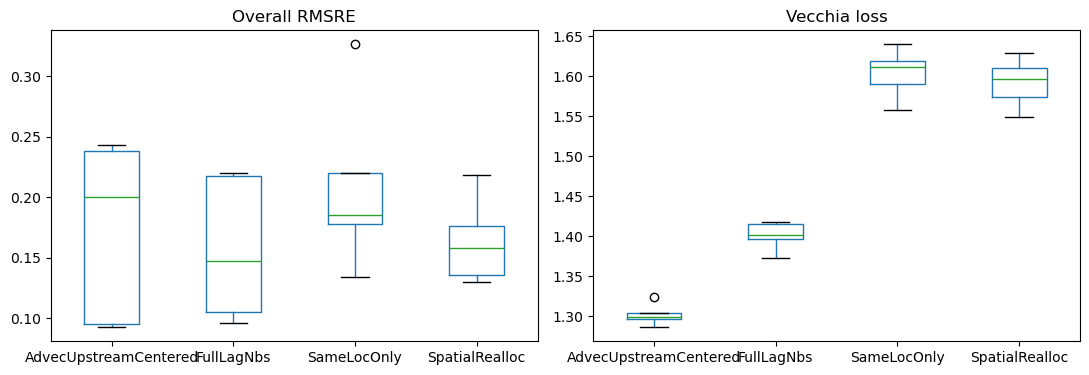

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df_results.boxplot(column="rmsre", by="model", ax=axes[0], grid=False)
axes[0].set_title("Overall RMSRE")
axes[0].set_xlabel("")
df_results.boxplot(column="loss", by="model", ax=axes[1], grid=False)
axes[1].set_title("Vecchia loss")
axes[1].set_xlabel("")
fig.suptitle("")
plt.tight_layout()
plt.show()

## How to read the result

- If `FullLagNbs` wins, same-location-centered previous-lag neighborhoods are better for this simulated DGP, supporting the Eulerian local-temporal-structure view.
- If `AdvecUpstreamCentered` wins, upstream-centered previous-lag neighborhoods better capture transport/advection in this simulation.
- If `SameLocOnly` is close to `FullLagNbs`, most temporal information may be captured by same-location lags alone.
- If `SpatialRealloc` wins, the removed previous-lag neighbor budget is more useful as extra current-time spatial information for this simulation setting.

`SameLocOnly` and `SpatialRealloc` are diagnostics, not the main fair competitor to `AdvecUpstreamCentered`. The main fair comparison is `FullLagNbs` vs `AdvecUpstreamCentered`, because both keep comparable lag-wise conditioning budgets.
